Data Analysis on Covid-19 global data

Importing the pandas, numpy library

In [1]:
import pandas as pd
import numpy as np

Data Collection:

In [5]:
df = pd.read_csv('owid-covid-data.csv')
print(df.columns)
df.head()
df.isnull().sum()

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

iso_code                                        0
continent                                   26525
location                                        0
date                                            0
total_cases                                 17631
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       416024
excess_mortality_cumulative                416024
excess_mortality                           416024
excess_mortality_cumulative_per_million    416024
Length: 67, dtype: int64

Data Cleaning


In [19]:
#filtering
df = df[df["location"].isin(["Kenya", "USA", "India"])]


print(df)
df = df.dropna(subset=['date', 'total_cases', 'total_deaths'])
df['date'] = pd.to_datetime(df['date'])
df[['total_cases', 'total_deaths', 'new_cases', 'new_deaths', 'total_vaccinations']] = df[
    ['total_cases', 'total_deaths', 'new_cases', 'new_deaths', 'total_vaccinations']
].fillna(method='ffill')
countries = ["Kenya", "USA", "India"]


       iso_code continent location       date  total_cases  new_cases  \
173549      IND      Asia    India 2020-01-05          0.0        0.0   
173550      IND      Asia    India 2020-01-06          0.0        0.0   
173551      IND      Asia    India 2020-01-07          0.0        0.0   
173552      IND      Asia    India 2020-01-08          0.0        0.0   
173553      IND      Asia    India 2020-01-09          0.0        0.0   
...         ...       ...      ...        ...          ...        ...   
196991      KEN    Africa    Kenya 2024-07-31     344106.0        0.0   
196992      KEN    Africa    Kenya 2024-08-01     344106.0        0.0   
196993      KEN    Africa    Kenya 2024-08-02     344106.0        0.0   
196994      KEN    Africa    Kenya 2024-08-03     344106.0        0.0   
196995      KEN    Africa    Kenya 2024-08-04     344106.0        0.0   

        new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  \
173549                 NaN           0.0      

Visualization

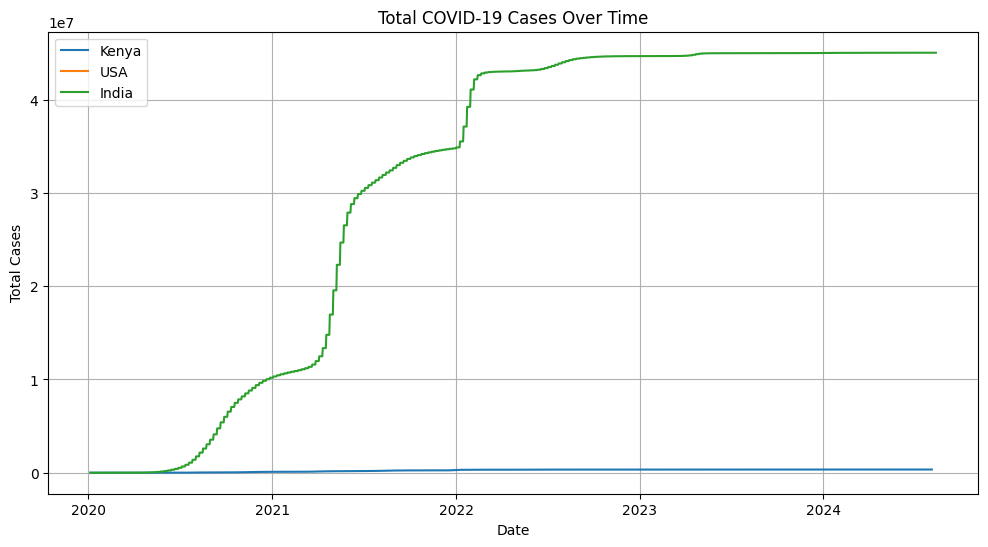

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
for country in countries:
    data = df[df['location'] == country]
    plt.plot(data['date'], data['total_cases'], label=country)
plt.title("Total COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.legend()
plt.grid(True)
plt.show()


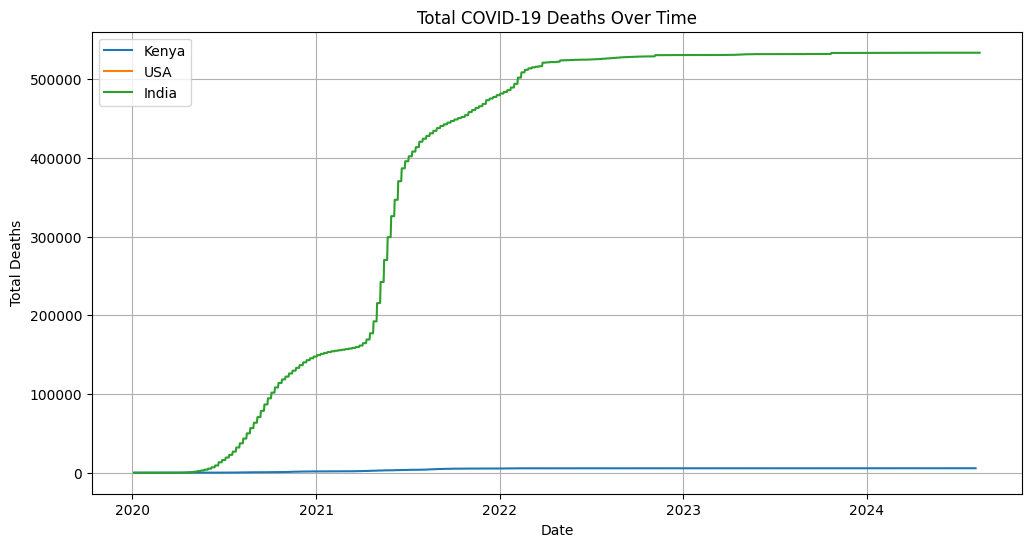

In [21]:
# Total deaths over time
plt.figure(figsize=(12,6))
for country in countries:
    data = df[df['location'] == country]
    plt.plot(data['date'], data['total_deaths'], label=country)
plt.title("Total COVID-19 Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("Total Deaths")
plt.legend()
plt.grid(True)
plt.show()


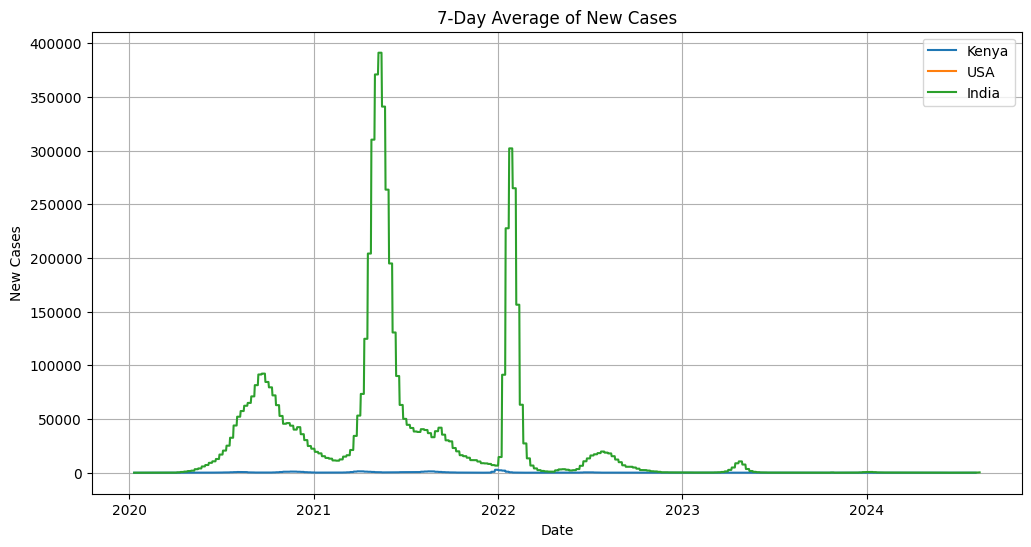

In [22]:
# Compare daily new cases
plt.figure(figsize=(12,6))
for country in countries:
    data = df[df['location'] == country]
    plt.plot(data['date'], data['new_cases'].rolling(7).mean(), label=country)
plt.title("7-Day Average of New Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.legend()
plt.grid(True)
plt.show()


In [23]:
# Calculate death rate
df['death_rate'] = df['total_deaths'] / df['total_cases']


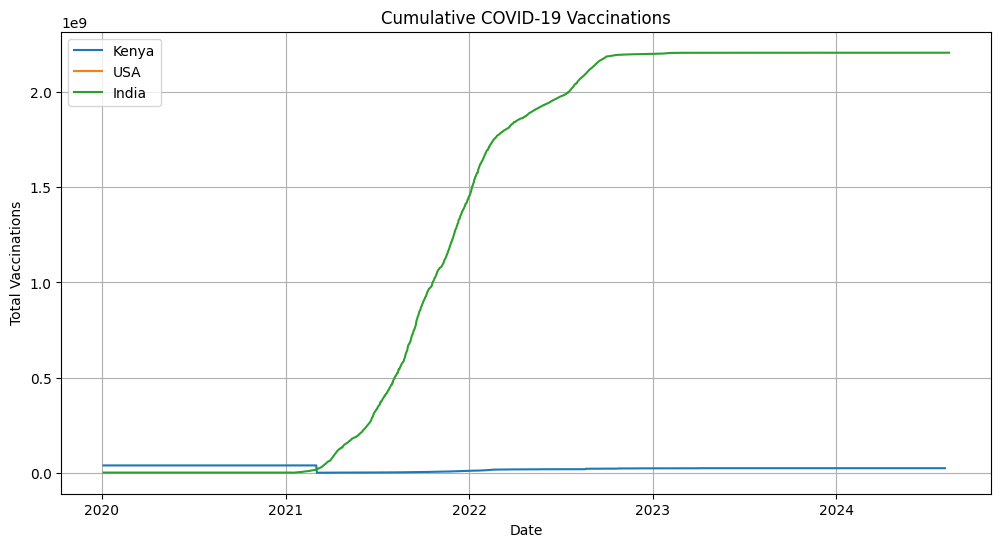

In [24]:
plt.figure(figsize=(12,6))
for country in countries:
    data = df[df['location'] == country]
    plt.plot(data['date'], data['total_vaccinations'], label=country)
plt.title("Cumulative COVID-19 Vaccinations")
plt.xlabel("Date")
plt.ylabel("Total Vaccinations")
plt.legend()
plt.grid(True)
plt.show()


7️⃣ Insights & Reporting

Key Insights:
United States recorded the highest total cases and deaths among the selected countries.

India experienced large spikes in new cases during mid-2021.

Kenya had comparatively fewer cases and a slower vaccination rollout.

Death rate trends showed higher initial ratios that decreased over time with improved treatment and vaccines.

Vaccination efforts were faster in the US, followed by India and Kenya